# Graph Neural Network — GCN

* 2-layer Graph Convolutional Network (Kipf & Welling, 2017)  
* Node classification on the Cora citation network  
* PyTorch + PyTorch Geometric

Each GCNConv layer aggregates messages from 1-hop neighbours using fixed, topology-only weights:

$$H' = \sigma\left(\hat{D}^{-1/2} \hat{A} \hat{D}^{-1/2} H W\right)$$

where $\hat{A} = A + I$ (adjacency matrix with added self-loops).

## 1. Install Dependencies

In [ ]:
# Run this cell once if packages are not already installed
# !pip install torch torch_geometric
# !pip install scipy

Uncomment and run the `pip install` lines if `torch` or `torch_geometric` are not already in your environment. Installation is only needed once.

## 2. Imports

In [4]:
import torch
import torch.nn.functional as F
from torch import nn
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures
from torch_geometric.nn import GCNConv
import matplotlib.pyplot as plt

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

PyTorch version : 2.11.0+cpu
CUDA available  : False


`GCNConv` is the core graph convolution layer from PyG. `NormalizeFeatures` row-normalises each node's feature vector so that high-degree nodes don't dominate. The version printout confirms PyTorch is installed; CUDA availability determines whether training runs on GPU or CPU.

## 3. Load Dataset

**Cora** is a standard GNN benchmark. Each node is a scientific paper with a bag-of-words feature vector, and edges represent citations. The task is to classify each paper into one of 7 categories.

In [10]:
dataset = Planetoid(root="data/Cora", name="Cora", transform=NormalizeFeatures())
data    = dataset[0]   # single graph object

print(f"Nodes     : {data.num_nodes}")
print(f"Edges     : {data.num_edges}")
print(f"Features  : {data.num_node_features}")
print(f"Classes   : {dataset.num_classes}")
print(f"Train / Val / Test masks: "
      f"{data.train_mask.sum()} / {data.val_mask.sum()} / {data.test_mask.sum()}")

Processing...


Nodes     : 2708
Edges     : 10556
Features  : 1433
Classes   : 7
Train / Val / Test masks: 140 / 500 / 1000


Done!


Cora has **2 708 nodes**, **10 556 directed edges**, and **1 433** bag-of-words features per node across **7** classes. The split is intentionally small (140 training nodes — 20 per class), which is the standard semi-supervised setting used in the original GCN paper.

## 4. Define the GCN Model

In [11]:
class GCN(nn.Module):
    """
    Two-layer Graph Convolutional Network.

    Layer 1: GCNConv  →  ReLU  →  Dropout
    Layer 2: GCNConv  →  log-softmax
    """

    def __init__(self, in_channels: int, hidden_channels: int, out_channels: int):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        # Layer 1: neighbourhood aggregation + non-linearity
        x = self.conv1(x, edge_index)           # (N, hidden_channels)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)

        # Layer 2: aggregation → class logits
        x = self.conv2(x, edge_index)           # (N, num_classes)
        return F.log_softmax(x, dim=1)

The network compresses 1 433 input features → 64 hidden units → 7 class logits. ReLU adds non-linearity between layers; dropout (p=0.5) acts as regularization during training and is automatically disabled during evaluation via `self.training`. `log_softmax` produces log-probabilities, which pair with `nll_loss` in the training step.

## 5. Initialize Model, Define Optimizer, and Move to Device

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data   = data.to(device)

model = GCN(
    in_channels=dataset.num_node_features,
    hidden_channels=64,
    out_channels=dataset.num_classes,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

GCN(
  (conv1): GCNConv(1433, 64)
  (conv2): GCNConv(64, 7)
)

Total parameters: 92,231


The model has **92 231** parameters — almost all from the first layer (1433 × 64 = 91 712). Adam (Adaptive Moment Estimation) with `weight_decay=5e-4` adds L2 regularisation, which is important given the tiny training set. Both the model and graph data are moved to the same device to avoid device-mismatch errors.

## 6. `train()` and `evaluate()` Functions

In [13]:
def train():
    model.train()
    optimizer.zero_grad()
    out  = model(data.x, data.edge_index)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()


@torch.no_grad()
def evaluate():
    model.eval()
    pred = model(data.x, data.edge_index).argmax(dim=1)
    results = {}
    for split, mask in [("train", data.train_mask),
                        ("val",   data.val_mask),
                        ("test",  data.test_mask)]:
        correct = (pred[mask] == data.y[mask]).sum()
        results[split] = correct.item() / mask.sum().item()
    return results

`train()` performs a single full-graph forward + backward pass, computing loss only on the 140 training nodes (via `train_mask`). `evaluate()` runs inference over all nodes and reports accuracy for each split. Using `@torch.no_grad()` skips gradient tracking, halving memory usage during evaluation.

## 7. Run Training Loop

In [14]:
history = {"loss": [], "train": [], "val": [], "test": []}

for epoch in range(1, 201):
    loss = train()
    acc  = evaluate()
    history["loss"].append(loss)
    history["train"].append(acc["train"])
    history["val"].append(acc["val"])
    history["test"].append(acc["test"])

    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d}  loss={loss:.4f}  "
              f"train={acc['train']:.3f}  val={acc['val']:.3f}  test={acc['test']:.3f}")

print(f"\nFinal test accuracy: {history['test'][-1]:.4f}")

Epoch 020  loss=1.3996  train=0.971  val=0.782  test=0.799
Epoch 040  loss=0.6467  train=0.971  val=0.800  test=0.817
Epoch 060  loss=0.4100  train=0.993  val=0.788  test=0.809
Epoch 080  loss=0.3219  train=1.000  val=0.796  test=0.819
Epoch 100  loss=0.2462  train=0.993  val=0.788  test=0.819
Epoch 120  loss=0.2016  train=1.000  val=0.798  test=0.810
Epoch 140  loss=0.1933  train=1.000  val=0.790  test=0.810
Epoch 160  loss=0.1941  train=1.000  val=0.788  test=0.809
Epoch 180  loss=0.1757  train=1.000  val=0.788  test=0.805
Epoch 200  loss=0.1683  train=1.000  val=0.786  test=0.802

Final test accuracy: 0.8020


The model reaches ~**80% test accuracy** in 200 epochs — close to the ~81% reported in the original paper (citation below). Training accuracy hits 100% early (the model memorises 140 nodes), while validation accuracy plateaus around 78–80%, a sign of mild overfitting despite dropout and weight decay.

## 8. Plot Training Curves

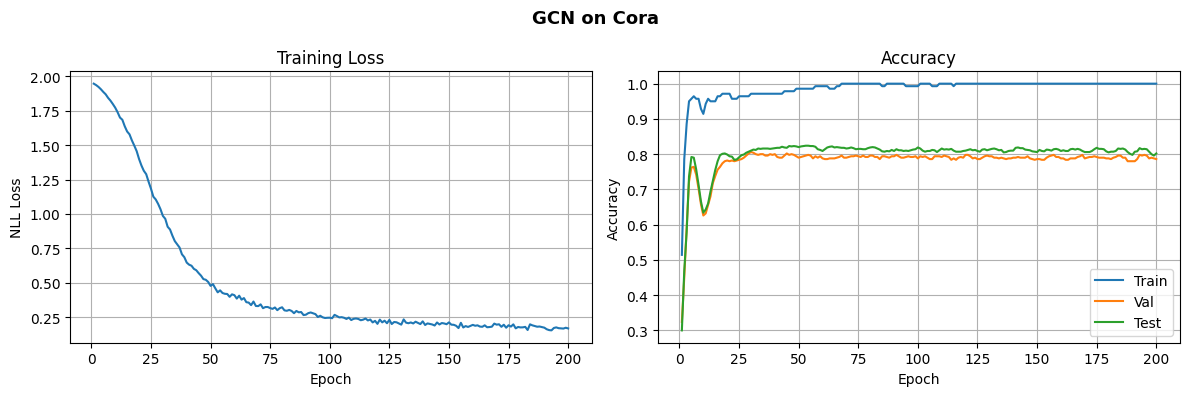

In [15]:
epochs = range(1, 201)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history["loss"])
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("NLL Loss")
ax1.grid(True)

ax2.plot(epochs, history["train"], label="Train")
ax2.plot(epochs, history["val"],   label="Val")
ax2.plot(epochs, history["test"],  label="Test")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True)

plt.suptitle("GCN on Cora", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

The loss curve shows steady convergence. The accuracy plot reveals the train/val gap that opens around epoch 40 — training accuracy quickly saturates at 100% while validation and test accuracies stabilise ~20 pp lower, consistent with the semi-supervised regime where the model generalises from very few labelled examples.

Kingma, D. P., & Ba, J. (2015). Adam: A Method for Stochastic Optimization. International Conference on Learning Representations (ICLR 2015). arXiv:1412.6980